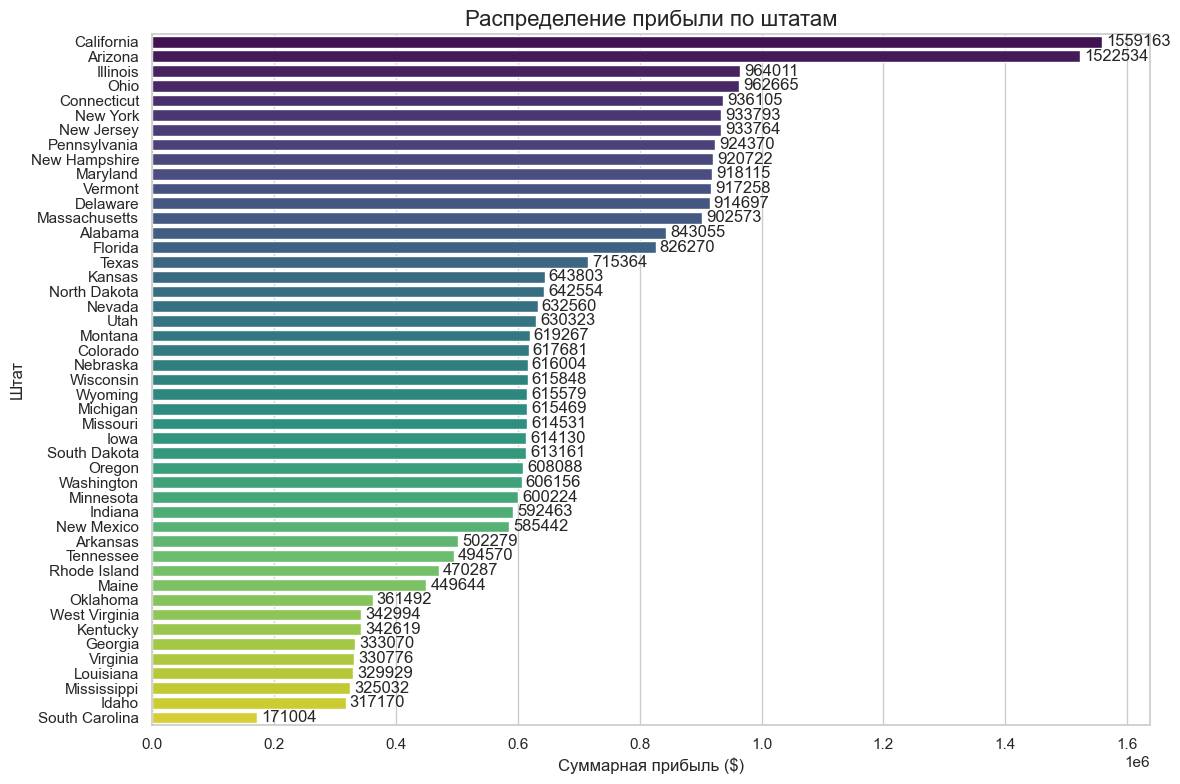

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загрузка файла
df = pd.read_csv('product_sales_dataset_final.csv')

# 2. Очистка названий колонок
# Сначала убираем внешние кавычки, затем лишние пробелы
df.columns = [col.replace("'", "").strip() for col in df.columns]

# 3. Визуализация
if 'State' in df.columns and 'Profit' in df.columns:
    state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False).reset_index()

    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")
    
    plot = sns.barplot(
    data=state_profit, 
    x='Profit', 
    y='State', 
    hue='State',      # Назначаем переменную State параметру hue
    palette='viridis', 
    legend=False      # Отключаем легенду, так как штаты уже указаны на оси Y
)
    
    plt.title('Распределение прибыли по штатам', fontsize=16)
    plt.xlabel('Суммарная прибыль ($)', fontsize=12)
    plt.ylabel('Штат', fontsize=12)

    for i in plot.containers:
        plot.bar_label(i, padding=3, fmt='%.0f')

    plt.tight_layout()
    plt.show()
else:
    print("Колонки все еще не найдены. Проверьте вывод 'Очищенные колонки' выше.")

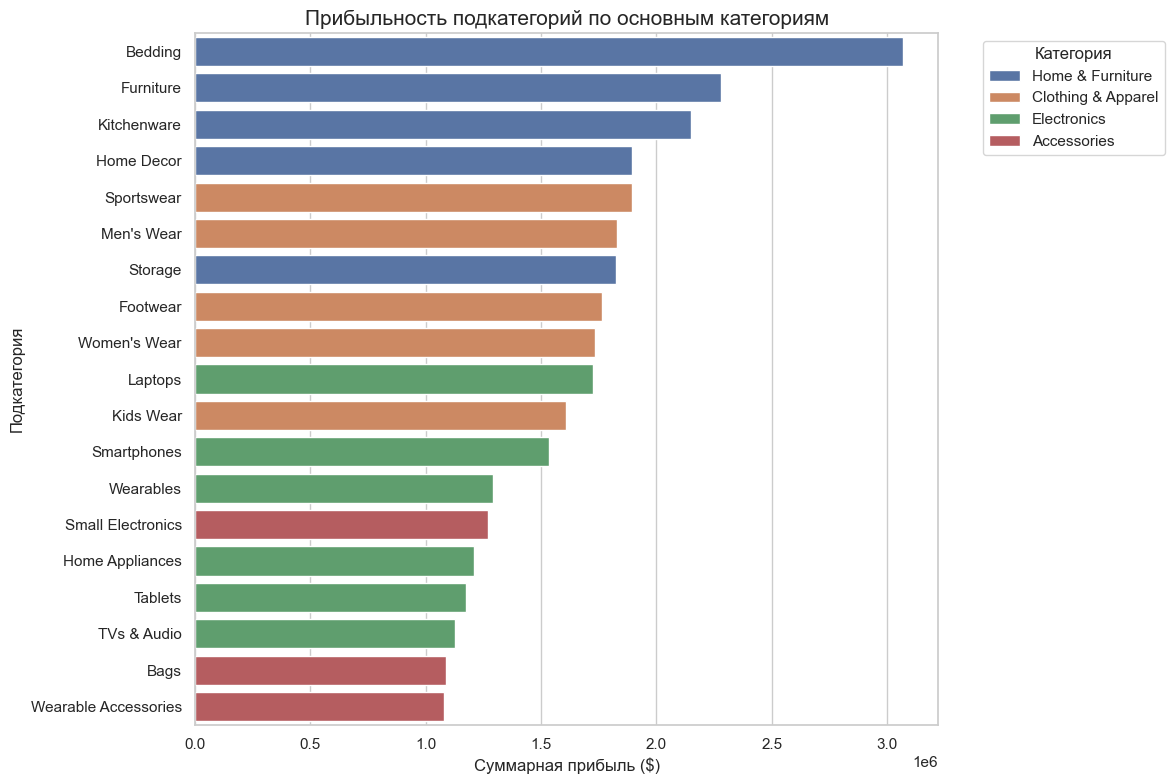

In [2]:
# Агрегируем данные по категориям
category_profit = df.groupby(['Category', 'Sub_Category'])['Profit'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(
    data=category_profit, 
    x='Profit', 
    y='Sub_Category', 
    hue='Category', 
    dodge=False
)

plt.title('Прибыльность подкатегорий по основным категориям', fontsize=15)
plt.xlabel('Суммарная прибыль ($)')
plt.ylabel('Подкатегория')
plt.legend(title='Категория', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Подготовка признаков (Features) и целевой переменной (Target)
# Выбираем факторы, которые могут влиять на прибыль
features = ['State', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price']
X = pd.get_dummies(df[features], drop_first=True) # Кодируем текст в 0 и 1 (One-Hot Encoding)
y = df['Profit']

# 2. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Обучение модели
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Оценка результата
predictions = model.predict(X_test)
print(f"Средняя ошибка (MAE): ${mean_absolute_error(y_test, predictions):.2f}")
print(f"Точность модели (R2 Score): {r2_score(y_test, predictions):.2f}")

Средняя ошибка (MAE): $37.16
Точность модели (R2 Score): 0.84


In [13]:
# Получаем массив предсказанных значений прибыли
y_pred = model.predict(X_test)

# Создаем DataFrame для наглядного сравнения (первые 10 значений)
comparison = pd.DataFrame({'Реальность': y_test, 'Предсказание': y_pred})
print(comparison.head(10))

        Реальность  Предсказание
119737       57.60       41.9255
72272       192.14      326.2597
158154      216.28      213.9067
65426       355.51      335.1415
30074       105.23      111.5716
23677       418.42      322.1266
134858      108.14      119.2512
176418      103.98      120.6006
132467      110.21       80.8610
4082        152.00      108.6599


Прогнозируемая прибыль для этого заказа: $354.71


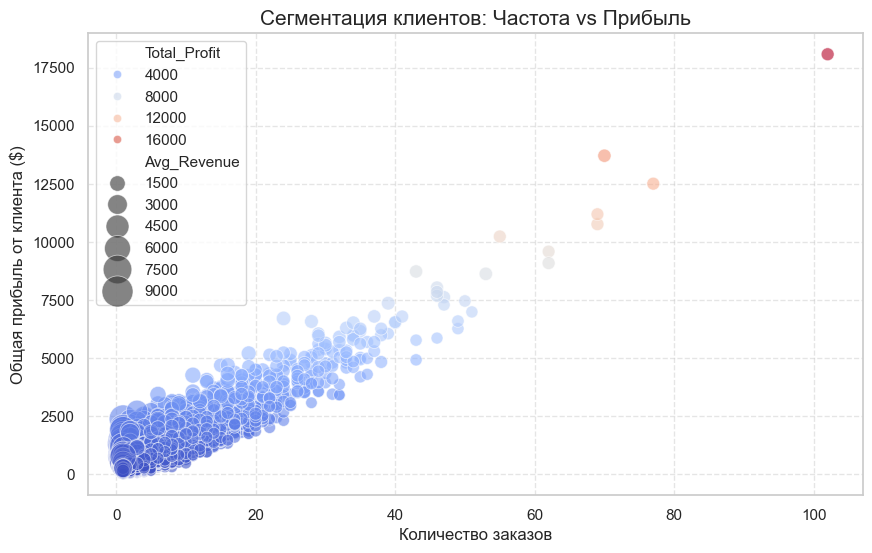

Топ-5 клиентов по прибыли:
                   Frequency  Total_Profit  Avg_Revenue
Customer_Name                                          
Michael Smith            102      18081.21   749.168725
Michael Williams          70      13714.20   844.796143
Michael Johnson           77      12510.80   731.080779
David Smith               69      11196.50   702.165072
Christopher Smith         69      10767.36   743.655072


In [12]:
# Агрегируем данные по каждому клиенту
customer_analysis = df.groupby('Customer_Name').agg({
    'Order_ID': 'count',  # Частота покупок
    'Profit': 'sum',      # Суммарная прибыль
    'Revenue': 'mean'     # Средний чек
}).rename(columns={'Order_ID': 'Frequency', 'Profit': 'Total_Profit', 'Revenue': 'Avg_Revenue'})

# Визуализация: Вклад клиента в прибыль vs Частота покупок
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customer_analysis, 
    x='Frequency', 
    y='Total_Profit', 
    size='Avg_Revenue', 
    sizes=(50, 500), 
    alpha=0.6,
    hue='Total_Profit',
    palette='coolwarm'
)

plt.title('Сегментация клиентов: Частота vs Прибыль', fontsize=15)
plt.xlabel('Количество заказов')
plt.ylabel('Общая прибыль от клиента ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Топ-5 самых ценных клиентов
print("Топ-5 клиентов по прибыли:")
print(customer_analysis.sort_values(by='Total_Profit', ascending=False).head())